# 로드한 데이터셋을 이용하여 최적의 모델을 설계후 학습된 모델을 완성하세요
1. 우리가 형성한 데이터셋 함수를 이용하여 데이터를 늘리시오. (최대 3000장)
2. 학습. 테스트, 검증 데이터셋을 구성하여 사용하시오.
3. 데이터 스케일링은 계층을 이용하시오.
4. 데이터 증강 계층을 사용하시오(1번 모델은 사용 안함, 2번 모델은 사용함. 단, 데이터는 변경 되면 안됨)
5. 반드시 학습이 완료된 모델은 저장 되어야 한다. (콜백함수 활용하시오)
6. 선정 내용을 문서로 정리하시오

In [11]:
# ===== 라이브러리 임포트 =====

# 시스템 및 파일 관리
import os
import shutil
import pathlib

# 데이터 분석 및 시각화
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 머신러닝 도구
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, classification_report, f1_score, mean_squared_error

# Keras 모델 관련
from keras.models import Sequential, load_model

# Keras 레이어
from keras.layers import (
   Input, Dense, Conv2D, MaxPooling2D, Dropout, 
   SimpleRNN, LSTM, GRU, BatchNormalization, 
   Flatten, Activation, Rescaling
)

# 데이터 증강 레이어
from keras.layers import RandomFlip, RandomRotation, RandomZoom

# 최적화 알고리즘
from keras.optimizers import Adam, RMSprop, SGD, Adagrad

# 손실 함수
from keras.losses import (
   binary_crossentropy, categorical_crossentropy, 
   sparse_categorical_crossentropy, mean_squared_error
)

# 콜백 함수
from keras.callbacks import EarlyStopping, ModelCheckpoint

In [12]:
# 데이터 생성
old_dir = pathlib.Path('dogs-vs-cats/train')
new_dir = pathlib.Path('dogs-vs-cats_test_data')

if os.path.exists(new_dir):
    shutil.rmtree(new_dir)
os.makedirs(new_dir)

def make_subset(sub_n, s_idx, e_idx):
    for i in ['cat', 'dog']:
        dir = new_dir/sub_n/i
        os.makedirs(dir)
        f_ns = [ f'{i}.{n}.jpg' for n in range(s_idx, e_idx)]
        for f_n in f_ns:
            shutil.copyfile(src=old_dir/f_n, dst=dir/f_n)

make_subset('tr_data', 0, 5000)
make_subset('tt_data', 5000, 10000)

tr_ds=image_dataset_from_directory(new_dir/'tr_data',image_size=(180,180), seed=42, validation_split=0.2, subset='training')
val_ds=image_dataset_from_directory(new_dir/'tr_data',image_size=(180,180), seed=42,validation_split=0.2, subset='validation')
tt_ds=image_dataset_from_directory(new_dir/'tt_data',image_size=(180,180), seed=42)

Found 10000 files belonging to 2 classes.
Using 8000 files for training.
Found 10000 files belonging to 2 classes.
Using 2000 files for validation.
Found 10000 files belonging to 2 classes.


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_6 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 180, 180, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 90, 90, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 90, 90, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 45, 45, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 45, 45, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 22, 22, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 22, 22, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 11, 11, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │     3,965,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,353,601 (16.61 MB)

 Trainable params: 4,353,601 (16.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - acc: 0.5318 - loss: 0.6911
Epoch 1: val_loss improved from inf to 0.62339, saving model to best_m.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 12s 44ms/step - acc: 0.5320 - loss: 0.6910 - val_acc: 0.6600 - val_loss: 0.6234
Epoch 2/100
249/250 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - acc: 0.6796 - loss: 0.6047
Epoch 2: val_loss improved from 0.62339 to 0.57224, saving model to best_m.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 11s 42ms/step - acc: 0.6797 - loss: 0.6046 - val_acc: 0.7075 - val_loss: 0.5722
Epoch 3/100
249/250 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - acc: 0.7293 - loss: 0.5436
Epoch 3: val_loss improved from 0.57224 to 0.54857, saving model to best_m.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - acc: 0.7293 - loss: 0.5436 - val_acc: 0.7130 - val_loss: 0.5486
Epoch 4/100
249/250 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - acc: 0.7646 - loss: 0.4945
Epoch 4: val_loss improved from 0.54857 to 0.50468, saving model to best_m.keras
250/250 ━━━━━━━━━━━━━

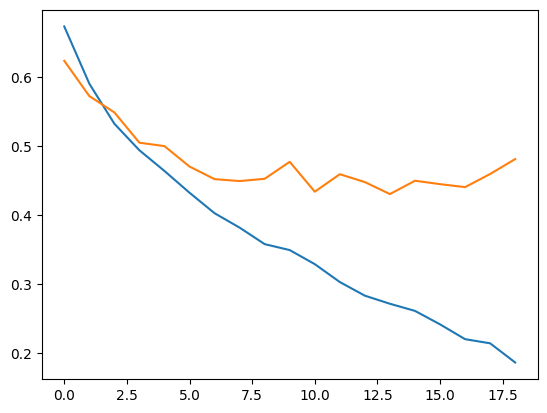

In [13]:
# 모델 생성 (데이터 증강 전)
m = Sequential()
m.add(Input(shape=(180, 180, 3)))
m.add(Rescaling(scale=1./255))
m.add(Conv2D(32, 3, 1, padding='same', activation='relu'))
m.add(MaxPooling2D(2))
m.add(Conv2D(64, 3, 1, padding='same', activation='relu'))
m.add(MaxPooling2D(2))
m.add(Conv2D(128, 3, 1, padding='same', activation='relu'))
m.add(MaxPooling2D(2))
# m.add(BatchNormalization())
m.add(Conv2D(256, 3, 1, padding='same', activation='relu'))
m.add(MaxPooling2D(2))
# m.add(BatchNormalization())
m.add(Flatten())
m.add(Dense(128, activation='relu'))
m.add(Dense(1, activation='sigmoid'))

m.summary()

m_ck1 = ModelCheckpoint('best_m.keras', save_best_only=True, verbose=1)
m_ck2 = EarlyStopping(monitor='val_loss', patience=5, verbose=1)
adam = Adam(learning_rate=0.0001)

m.compile(loss='binary_crossentropy', metrics=['acc'], optimizer=adam)
history_m = m.fit(tr_ds, epochs=100, callbacks=[m_ck1,m_ck2], validation_data=val_ds, verbose=1)

# 그래프 확인
plt.plot(history_m.history['loss'])
plt.plot(history_m.history['val_loss'])

In [24]:

# 모델 생성 (데이터 증강 후)
data_add_m = Sequential()
data_add_m.add(Input(shape=(180, 180, 3)))

data_add_m.add(Rescaling(scale=1./255))

data_add_m.add(RandomZoom(0.2))
data_add_m.add(RandomRotation(0.1))

data_add_m.add(Conv2D(32, 3, 1, padding='same', activation='relu'))
# data_add_m.add(Conv2D(32, 3, 1, padding='same', activation='relu'))
data_add_m.add(MaxPooling2D(2))
# data_add_m.add(Dropout(0.2))
data_add_m.add(BatchNormalization())
data_add_m.add(Conv2D(64, 3, 1, padding='same', activation='relu'))
# data_add_m.add(Conv2D(64, 3, 1, padding='same', activation='relu'))
data_add_m.add(MaxPooling2D(2))
# data_add_m.add(Dropout(0.2))
data_add_m.add(BatchNormalization())
data_add_m.add(Conv2D(128, 3, 1, padding='same', activation='relu'))
# data_add_m.add(Conv2D(128, 3, 1, padding='same', activation='relu'))
data_add_m.add(MaxPooling2D(2))
# data_add_m.add(Dropout(0.2))
data_add_m.add(BatchNormalization())
data_add_m.add(Conv2D(256, 3, 1, padding='same', activation='relu'))
# data_add_m.add(Conv2D(256, 3, 1, padding='same', activation='relu'))
data_add_m.add(MaxPooling2D(2))
# data_add_m.add(Dropout(0.2))
data_add_m.add(BatchNormalization())
data_add_m.add(Flatten())
data_add_m.add(Dense(128, activation='relu'))
data_add_m.add(Dense(64, activation='relu'))
data_add_m.add(Dense(32, activation='relu'))
data_add_m.add(Dense(1, activation='sigmoid'))

data_add_m.summary()

data_add_m_ck1 = ModelCheckpoint('best_add_m_1.keras', save_best_only=True, verbose=1)
data_add_m_ck2 = EarlyStopping(monitor='val_loss', patience=15, verbose=1)
adam = Adam(learning_rate=0.0002)

# 모델 컴파일 및 학습
data_add_m.compile(loss='binary_crossentropy', metrics=['acc'], optimizer=adam)
history_add_m = data_add_m.fit(tr_ds, epochs=100, callbacks=[data_add_m_ck1, data_add_m_ck2], validation_data=val_ds, verbose=1, batch_size=16)

# 그래프 확인
plt.plot(history_add_m.history['loss'])
plt.plot(history_add_m.history['val_loss'])

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_15 (Rescaling)        │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_12 (RandomZoom)     │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_12              │ (None, 180, 180, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_64 (Conv2D)              │ (None, 180, 180, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_60 (MaxPooling2D) │ (None, 90, 90, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 90, 90, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_65 (Conv2D)              │ (None, 90, 90, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_61 (MaxPooling2D) │ (None, 45, 45, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 45, 45, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_66 (Conv2D)              │ (None, 45, 45, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_62 (MaxPooling2D) │ (None, 22, 22, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 22, 22, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_67 (Conv2D)              │ (None, 22, 22, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_63 (MaxPooling2D) │ (None, 11, 11, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 11, 11, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_15 (Flatten)            │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 128)            │     3,965,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,365,761 (16.65 MB)

 Trainable params: 4,364,801 (16.65 MB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - acc: 0.5988 - loss: 1.2722
Epoch 1: val_loss improved from inf to 3.15031, saving model to best_add_m_1.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 20s 69ms/step - acc: 0.5988 - loss: 1.2719 - val_acc: 0.4900 - val_loss: 3.1503
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - acc: 0.6072 - loss: 1.3206
Epoch 2: val_loss improved from 3.15031 to 2.75853, saving model to best_add_m_1.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 17s 67ms/step - acc: 0.6072 - loss: 1.3208 - val_acc: 0.5290 - val_loss: 2.7585
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - acc: 0.5807 - loss: 1.4931
Epoch 3: val_loss did not improve from 2.75853
250/250 ━━━━━━━━━━━━━━━━━━━━ 17s 68ms/step - acc: 0.5806 - loss: 1.4952 - val_acc: 0.5420 - val_loss: 2.9368
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - acc: 0.5758 - loss: 2.4403
Epoch 4: val_loss improved from 2.75853 to 2.50555, saving model to best_add_m_1.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 17s 69ms

KeyboardInterrupt: 

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_17 (Rescaling)        │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_14 (RandomZoom)     │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_14              │ (None, 180, 180, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_76 (Conv2D)              │ (None, 180, 180, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 180, 180, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_77 (Conv2D)              │ (None, 180, 180, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 180, 180, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_68 (MaxPooling2D) │ (None, 90, 90, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 90, 90, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_78 (Conv2D)              │ (None, 90, 90, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 90, 90, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_79 (Conv2D)              │ (None, 90, 90, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 90, 90, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_69 (MaxPooling2D) │ (None, 45, 45, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 45, 45, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_80 (Conv2D)              │ (None, 45, 45, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 45, 45, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_81 (Conv2D)              │ (None, 45, 45, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 45, 45, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_70 (MaxPooling2D) │ (None, 22, 22, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 22, 22, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 5,141,793 (19.61 MB)

 Trainable params: 5,139,617 (19.61 MB)

 Non-trainable params: 2,176 (8.50 KB)

Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - acc: 0.5845 - loss: 0.9005
Epoch 1: val_loss improved from inf to 1.71309, saving model to best_add_m_1.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 50s 181ms/step - acc: 0.5846 - loss: 0.9002 - val_acc: 0.4900 - val_loss: 1.7131
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - acc: 0.6472 - loss: 0.6957
Epoch 2: val_loss improved from 1.71309 to 1.27559, saving model to best_add_m_1.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 45s 178ms/step - acc: 0.6472 - loss: 0.6957 - val_acc: 0.5240 - val_loss: 1.2756
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - acc: 0.6841 - loss: 0.6408
Epoch 3: val_loss improved from 1.27559 to 0.79411, saving model to best_add_m_1.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 45s 181ms/step - acc: 0.6841 - loss: 0.6407 - val_acc: 0.6325 - val_loss: 0.7941
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - acc: 0.7062 - loss: 0.5977
Epoch 4: val_loss improved from 0.79411 to 0.58932, saving model to best_add_

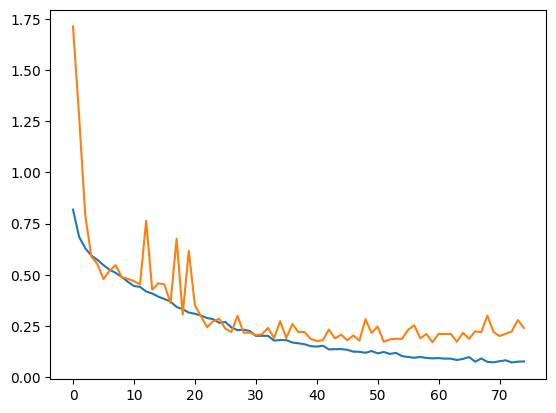

In [28]:
import tensorflow as tf
from tensorflow.keras import layers, models

# 모델 생성
data_add_m = models.Sequential()

# 데이터 증강 (Data Augmentation) 및 입력층
data_add_m.add(layers.Input(shape=(180, 180, 3)))
data_add_m.add(layers.Rescaling(1./255))
data_add_m.add(layers.RandomZoom(0.2))
data_add_m.add(layers.RandomRotation(0.1))

# 컨볼루션 블록 1
data_add_m.add(layers.Conv2D(32, (3, 3), padding='same', activation='relu'))
data_add_m.add(layers.BatchNormalization())
data_add_m.add(layers.Conv2D(32, (3, 3), padding='same', activation='relu'))
data_add_m.add(layers.BatchNormalization())
data_add_m.add(layers.MaxPooling2D(2))
data_add_m.add(layers.Dropout(0.3))

# 컨볼루션 블록 2
data_add_m.add(layers.Conv2D(64, (3, 3), padding='same', activation='relu'))
data_add_m.add(layers.BatchNormalization())
data_add_m.add(layers.Conv2D(64, (3, 3), padding='same', activation='relu'))
data_add_m.add(layers.BatchNormalization())
data_add_m.add(layers.MaxPooling2D(2))
data_add_m.add(layers.Dropout(0.3))

# 컨볼루션 블록 3
data_add_m.add(layers.Conv2D(128, (3, 3), padding='same', activation='relu'))
data_add_m.add(layers.BatchNormalization())
data_add_m.add(layers.Conv2D(128, (3, 3), padding='same', activation='relu'))
data_add_m.add(layers.BatchNormalization())
data_add_m.add(layers.MaxPooling2D(2))
data_add_m.add(layers.Dropout(0.3))

# 컨볼루션 블록 4
data_add_m.add(layers.Conv2D(256, (3, 3), padding='same', activation='relu'))
data_add_m.add(layers.BatchNormalization())
data_add_m.add(layers.Conv2D(256, (3, 3), padding='same', activation='relu'))
data_add_m.add(layers.BatchNormalization())
data_add_m.add(layers.MaxPooling2D(2))
data_add_m.add(layers.Dropout(0.3))

# 완전 연결 층 (Classification)
data_add_m.add(layers.Flatten())
data_add_m.add(layers.Dense(128, activation='relu'))
data_add_m.add(layers.BatchNormalization())
data_add_m.add(layers.Dropout(0.5))

# 최종 출력층 (Output Layer)
data_add_m.add(layers.Dense(1, activation='sigmoid'))

# 모델 요약
data_add_m.summary()

data_add_m_ck1 = ModelCheckpoint('best_add_m_1.keras', save_best_only=True, verbose=1)
data_add_m_ck2 = EarlyStopping(monitor='val_loss', patience=15, verbose=1)
adam = Adam(learning_rate=0.0002)

# 모델 컴파일 및 학습
data_add_m.compile(loss='binary_crossentropy', metrics=['acc'], optimizer=adam)
history_add_m = data_add_m.fit(tr_ds, epochs=100, callbacks=[data_add_m_ck1, data_add_m_ck2], validation_data=val_ds, verbose=1, batch_size=16)

# 그래프 확인
plt.plot(history_add_m.history['loss'])
plt.plot(history_add_m.history['val_loss'])

In [31]:
# 모델 평가
best_m = load_model('best_m.keras')
best_add_m = load_model('best_add_m_1.keras')

# 예측 및 결과 확인
# tr_scs_m = best_m.evaluate(tr_ds)
# val_scs_m = best_m.evaluate(val_ds)
# tt_scs_m = best_m.evaluate(tt_ds)

tr_scs_add = best_add_m.evaluate(tr_ds)
val_scs_add = best_add_m.evaluate(val_ds)
tt_scs_add = best_add_m.evaluate(tt_ds)

# all_acc_m=abs(tr_scs_m[1]-val_scs_m[1])+abs(tr_scs_m[1]-tt_scs_m[1])+abs(tt_scs_m[1]-val_scs_m[1])
# print(f'all_acc_m : {all_acc_m}')

all_acc_add=abs(tr_scs_add[1]-val_scs_add[1])+abs(tr_scs_add[1]-tt_scs_add[1])+abs(tt_scs_add[1]-val_scs_add[1])
print(f'all_acc_add : {all_acc_add}')

# all_loss_m=abs(tr_scs_m[0]-val_scs_m[0])+abs(tr_scs_m[0]-tt_scs_m[0])+abs(tt_scs_m[0]-val_scs_m[0])
# print(f'all_loss_m : {all_loss_m}')

all_loss_add=abs(tr_scs_add[0]-val_scs_add[0])+abs(tr_scs_add[0]-tt_scs_add[0])+abs(tt_scs_add[0]-val_scs_add[0])
print(f'all_loss_add : {all_loss_add}')

250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - acc: 0.9838 - loss: 0.0457
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - acc: 0.9445 - loss: 0.1798
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - acc: 0.9364 - loss: 0.1783
all_acc_add : 0.10130000114440918
all_loss_add : 0.26800686866045
